# phase  1: data loading and cleaning

**objective:**  load all raw data sheets, clean them individually, merge them into a final dataframe where each row represents one commune

## 1- Exploring relevant data sheets

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_name='../data/Indicateurs démographiques et socioéconomiques du Royaume du Maroc selon les résultats du RGPH 2024.xlsx'
code_geo_file='../data/codegeographique.xlsx'

xls=pd.ExcelFile(file_name)
all_sheet_names= xls.sheet_names
print("available sheets in the excel file")
print(all_sheet_names)

available sheets in the excel file
['Population', 'Population_Urbaine', 'Population_Rurale', 'Ménages', 'Ménages_Urbains', 'Ménages_Ruraux', 'Définitions_des_Concepts', 'Signes_Conventionnels', 'Avis_aux_Utilisateurs']


In [3]:
sheets_to_ignore =['Définitions_des_Concepts','Signes_Conventionnels', 'Avis_aux_Utilisateurs']
data_sheets=[sheet for sheet in all_sheet_names if sheet not in sheets_to_ignore]
print("final list of data sheet to process:", data_sheets)

final list of data sheet to process: ['Population', 'Population_Urbaine', 'Population_Rurale', 'Ménages', 'Ménages_Urbains', 'Ménages_Ruraux']


 Sheet Inventory :
*   `Population`: 
*   `Population_Urbaine`: 
*   `Population_Rurale`:
*   `ménages`: 
*   `ménages_Urbaine`: 
*   `ménages_Rurale`:


In [4]:

print("---peeking into relevant data sheets:---")

for sheet in data_sheets:
    print(f"---peeking into sheets:{sheet}---")
    df_peek=pd.read_excel(file_name, sheet_name=sheet, header=None, nrows=15)
    print(df_peek)

    

---peeking into relevant data sheets:---
---peeking into sheets:Population---
                               0                                    1    \
0   Milieu de résidence : Ensemble                                  NaN   
1                              NaN                                  NaN   
2                Code géographique          Collectivités territoriales   
3                              NaN      Ensemble du territoire national   
4                                1  Région de Tanger-Tétouan-Al Hoceima   
5                             1511         Préfecture de Tanger-Assilah   
6                          1511010                    Commune de Tanger   
7                         15110105            Arrondissement de Mghogha   
8                         15110106             Arrondissement de Souani   
9                         15110103         Arrondissement de Bni Makada   
10                        15110107             Arrondissement de Médina   
11                    

This allows for a visual inspection to determine the correct `header` and `skiprows` parameters needed for proper loading.

## 2- Creating our dataset

we will create the final dataset by sectionning excel sheets to 4 main blocks: geographical info, both genders, males and females

**Indexing our columns**


In [5]:
def excel_col_to_index(col_name):
    """Converts an Excel column name like 'A', 'B', 'AA', 'BQ' into a 0-indexed integer."""
    index = 0
    for char in col_name:
        index = index * 26 + (ord(char.upper()) - ord('A') + 1)
    return index - 1





**flattening our colums**: get rid of the hierarchical structure 

In [6]:
import re
def clean_all_column_names(df):
    new_cols=[]
    for col_tuple in df.columns:
        
        flat_col='_'.join([str(level) for level in col_tuple if 'unnamed' not in str(level).lower() and 'nan' not in str(level).lower()])
        
        new_cols.append(flat_col)
    df.columns=new_cols
    clean_cols=df.columns.to_series().astype(str)
    #remove unnamed
    clean_cols = clean_cols.str.replace(r'Unnamed:\s*\d+\s*', '', regex=True)
    
    #remove level followed by any number
    clean_cols=clean_cols.str.replace(r'_level_\d', '', regex=True)
    #remove a numberand an underscore at the start of a string
    clean_cols=clean_cols.str.replace(r'^\d+_', '', regex=True)
    #replace two or more underscores with  one underscore
    clean_cols=clean_cols.str.replace(r'_+', '_', regex=True)

    clean_cols = clean_cols.str.replace(r'^\d_', '', regex=True)
    
    #remove any underscore at the start or beginning
    clean_cols=clean_cols.str.strip('_')
    df.columns=clean_cols
    return df
    
    





**creating the base geographic dataframe**


In [7]:
df_code_geographique=pd.read_excel(code_geo_file)
df_Collectivites_territoriales=pd.read_excel(file_name, sheet_name=sheet, skiprows=[0, 2], usecols='B')
df_base_geo = pd.concat([df_code_geographique, df_Collectivites_territoriales], axis=1)
display(df_base_geo.head())

,Code géographique,Collectivités territoriales
0,01,Région de Tanger-Tétouan-Al Hoceima
1,01.511,Préfecture de Tanger-Assilah
2,01.511.01.0,Commune de Tanger
3,01.511.01.05,Arrondissement de Mghogha
4,01.511.01.06,Arrondissement de Souani


**"Population Processor" Function**:

*goal*:return a single, fully cleaned and joined DataFrame for one population( ensemble , urbaine or rurale) sheet.

*This function will take two arguments:* the file_name and the sheet_name.


In [8]:
start_col_index = excel_col_to_index('C')
end_col_index = excel_col_to_index('BO')

print(f"The 'EMSEMBLE' block starts at column index: {start_col_index}") 
print(f"The 'ENSEMBLE' block ends at column index: {end_col_index}")   


The 'EMSEMBLE' block starts at column index: 2
The 'ENSEMBLE' block ends at column index: 66


In [9]:

start_col_index = excel_col_to_index('BQ')
end_col_index = excel_col_to_index('DX')

print(f"The 'Masculin' block starts at column index: {start_col_index}") 
print(f"The 'Masculin' block ends at column index: {end_col_index}")   


The 'Masculin' block starts at column index: 68
The 'Masculin' block ends at column index: 127


In [10]:
start_col_index = excel_col_to_index('DZ')
end_col_index = excel_col_to_index('GI')

print(f"The 'sexe:Feminin' block starts at column index: {start_col_index}") 
print(f"The 'sexe:feminin' block ends at column index: {end_col_index}")   



The 'sexe:Feminin' block starts at column index: 129
The 'sexe:feminin' block ends at column index: 190


In [11]:
def process_population_sheet(file, sheet):
    
   
    
    print(f"processing population sheet:{sheet}")
    suffix=""
    if "Population_Urbaine" in sheet:
        suffix="_URBAIN"
    elif "Population_Rurale" in sheet:
        suffix="_RURALE"
    elif "Population" in sheet:
        suffix="_TOTAL"
    df_full_sheet=pd.read_excel(file,sheet_name=sheet,
                                  header=[0, 1],
                                  skiprows=[0,3],
                                  #na_values=na_placeholders 
                                
                                  )
   
    
   
    
    #for the Ensemble block:
    df_total_raw=df_full_sheet.iloc[:,2:67]

    df_total_clean=clean_all_column_names(df_total_raw)
    full_suffix_total='_ENSEMBLE'+ suffix
    df_total_clean=df_total_clean.add_suffix(full_suffix_total)

    #for the masculin block 
    df_masculin_raw=df_full_sheet.iloc[:,68:128]

    df_masculin_clean=clean_all_column_names(df_masculin_raw)
    full_suffix_total='_HOMMES'+ suffix
    df_masculin_clean=df_masculin_clean.add_suffix(full_suffix_total)
    
    df_masculin_clean.columns=df_masculin_clean.columns.str.replace('1_HOMMES', '_HOMMES', regex=False)
    # For the Féminin block:
    df_feminin_raw=df_full_sheet.iloc[:,129:191]
    full_suffix_feminin = '_FEMMES' + suffix

    df_feminin_clean=clean_all_column_names(df_feminin_raw)
    
    df_feminin_clean=df_feminin_clean.add_suffix(full_suffix_feminin)
    df_feminin_clean.columns=df_feminin_clean.columns.str.replace('2_FEMMES', '_FEMMES', regex=False)

    #join the blocks
    df_processed = pd.concat([ df_total_clean, df_masculin_clean, df_feminin_clean], axis=1)
    print(f"---{sheet} Shape before removing duplicate content: {df_processed.shape}")
    df_processed = df_processed.T.drop_duplicates().T
    print(f"  - Shape after removing duplicate content:  {df_processed.shape}")
    print(f"---finished processing {sheet}. Final Shape: {df_processed.shape}---")

    
    return df_processed

df_pop_total = process_population_sheet(file_name, 'Population')
df_pop_urbain = process_population_sheet(file_name, 'Population_Urbaine')
df_pop_rurale = process_population_sheet(file_name, 'Population_Rurale')



processing population sheet:Population
---Population Shape before removing duplicate content: (2016, 187)
  - Shape after removing duplicate content:  (2016, 179)
---finished processing Population. Final Shape: (2016, 179)---
processing population sheet:Population_Urbaine
---Population_Urbaine Shape before removing duplicate content: (2016, 187)
  - Shape after removing duplicate content:  (2016, 179)
---finished processing Population_Urbaine. Final Shape: (2016, 179)---
processing population sheet:Population_Rurale
---Population_Rurale Shape before removing duplicate content: (2016, 187)
  - Shape after removing duplicate content:  (2016, 179)
---finished processing Population_Rurale. Final Shape: (2016, 179)---


TOTALE STANDS FOR ALL OVER MOROCCO
ENSEMBLE STANDS FOR ALL GENDERS

in the master dataset the headers will be like this: titleofthecolumn_GENDER(H/F)_LOCATION(URBAIN/RURAL)

In [12]:
print(df_pop_total.head())


  Population légale_ENSEMBLE_TOTAL Population municipale_ENSEMBLE_TOTAL  \
0                          4030222                              4008655   
1                          1494413                              1487236   
2                          1275428                              1272718   
3                           252656                               252177   
4                           111772                               110723   

  Sexe (%)_Masculin_ENSEMBLE_TOTAL Sexe (%)_Féminin_ENSEMBLE_TOTAL  \
0                             50.8                            49.2   
1                             50.8                            49.2   
2                             50.6                            49.4   
3                             50.8                            49.2   
4                             48.4                            51.6   

  Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL  \
0                                        8.2   
1                               

In [13]:
display(df_pop_urbain.head())

,Population légale_ENSEMBLE_URBAIN,Population municipale_ENSEMBLE_URBAIN,Sexe (%)_Masculin_ENSEMBLE_URBAIN,Sexe (%)_Féminin_ENSEMBLE_URBAIN,Âge quinquennal (%)_0-4 ans_ENSEMBLE_URBAIN,Âge quinquennal (%)_5-9 ans_ENSEMBLE_URBAIN,Âge quinquennal (%)_10-14 ans_ENSEMBLE_URBAIN,Âge quinquennal (%)_15-19 ans_ENSEMBLE_URBAIN,Âge quinquennal (%)_20-24 ans_ENSEMBLE_URBAIN,Âge quinquennal (%)_25-29 ans_ENSEMBLE_URBAIN,...,Taux de chômage (%)_FEMMES_URBAIN,Population active occupée de 15 ans et plus_FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Employeur._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Indépendant._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Salarié du secteur public._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Salarié du secteur privé._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Aide familial._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Apprenti._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Coopérateur/Associé._FEMMES_URBAIN,Statut professionnel des actifs occupés de 15 ans et plus (%)_Autre._FEMMES_URBAIN
0,2638815,2626188,50.2,49.8,7.8,9.2,9,7.6,7.9,8.1,...,23.3,191272,1.5,8.8,17,69.1,0.8,0.3,0.8,1.7
1,1402668,1397890,50.7,49.3,8.4,9.3,8.7,7.4,8.4,9.1,...,17.8,123407,1.5,6.9,10.7,77.9,0.7,0.3,0.7,1.3
2,1275428,1272718,50.6,49.4,8.3,9.2,8.6,7.4,8.5,9.1,...,17.7,114125,1.5,6.8,10.4,78.4,0.7,0.3,0.7,1.3
3,252656,252177,50.8,49.2,8.2,9.3,9,7.6,8.5,9.1,...,20,21357,1.4,6.5,7.7,81.2,0.7,0.2,0.7,1.6
4,111772,110723,48.4,51.6,5.7,7.1,7.5,6.9,7.4,7.6,...,17.9,10972,1.7,9.2,16.9,68.9,1,0.2,0.5,1.5


In [14]:
display(df_pop_rurale.head())

,Population légale_ENSEMBLE_RURALE,Population municipale_ENSEMBLE_RURALE,Sexe (%)_Masculin_ENSEMBLE_RURALE,Sexe (%)_Féminin_ENSEMBLE_RURALE,Âge quinquennal (%)_0-4 ans_ENSEMBLE_RURALE,Âge quinquennal (%)_5-9 ans_ENSEMBLE_RURALE,Âge quinquennal (%)_10-14 ans_ENSEMBLE_RURALE,Âge quinquennal (%)_15-19 ans_ENSEMBLE_RURALE,Âge quinquennal (%)_20-24 ans_ENSEMBLE_RURALE,Âge quinquennal (%)_25-29 ans_ENSEMBLE_RURALE,...,Taux de chômage (%)_FEMMES_RURALE,Population active occupée de 15 ans et plus_FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Employeur._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Indépendant._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Salarié du secteur public._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Salarié du secteur privé._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Aide familial._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Apprenti._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Coopérateur/Associé._FEMMES_RURALE,Statut professionnel des actifs occupés de 15 ans et plus (%)_Autre._FEMMES_RURALE
0,1391407,1382467,51.9,48.1,8.8,10.2,10.2,8.6,7.3,7,...,21.4,41022,0.4,22.7,8.2,30.7,35.6,0.1,1.4,0.9
1,91745,89346,52.5,47.5,9.7,11,10.3,7.8,7.1,6.7,...,17.2,4353,1.1,21.8,4.8,53.2,18.2,0.2,0.4,0.4
2,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…
3,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…
4,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…


**"Menages Processor" Function**

In [15]:
def process_menages_sheet(file, sheet):
    print(f"processing menage sheet:{sheet}")
    suffix=""
    if "Ménages_Urbains" in sheet:
        suffix="_URBAIN"
    elif "Ménages_Ruraux" in sheet:
        suffix="_RURALE"
    elif "Ménages" in sheet:
        suffix="_TOTAL"
    df_full_sheet=pd.read_excel(file,sheet_name=sheet, 
                                skiprows=[2],
                                header=[0,1],
                                #na_values=na_placeholders 
                                  )
   
    
   
    
    
    df_total_raw=df_full_sheet.iloc[:,3:38]
    df_total_clean=clean_all_column_names(df_total_raw)
    df_total_clean=df_total_clean.rename(columns={'Ménages _Ménages population': 'Ménages', 'Taille moyenne des ménages_Taille moyenne': 'Taille moyenne des ménages' })

    
    
    df_processed=df_total_clean.add_suffix(suffix)

    print(f"---{sheet} Shape before removing duplicate content: {df_processed.shape}")
    df_processed = df_processed.T.drop_duplicates().T
    print(f"  - Shape after removing duplicate content:  {df_processed.shape}")
    print(f"---finished processing {sheet}. Final Shape: {df_processed.shape}---")

    
    
    

    
    
    return df_processed

df_menages_totaux = process_menages_sheet(file_name, 'Ménages')
df_menages_urbains = process_menages_sheet(file_name, 'Ménages_Urbains')
df_menages_ruraux = process_menages_sheet(file_name, 'Ménages_Ruraux')


processing menage sheet:Ménages
---Ménages Shape before removing duplicate content: (2016, 35)
  - Shape after removing duplicate content:  (2016, 35)
---finished processing Ménages. Final Shape: (2016, 35)---
processing menage sheet:Ménages_Urbains
---Ménages_Urbains Shape before removing duplicate content: (2016, 35)
  - Shape after removing duplicate content:  (2016, 35)
---finished processing Ménages_Urbains. Final Shape: (2016, 35)---
processing menage sheet:Ménages_Ruraux
---Ménages_Ruraux Shape before removing duplicate content: (2016, 35)
  - Shape after removing duplicate content:  (2016, 35)
---finished processing Ménages_Ruraux. Final Shape: (2016, 35)---


In [16]:
display(df_menages_totaux.head())

,Ménages_TOTAL,Taille moyenne des ménages_TOTAL,Ménages sédentaires_TOTAL,Type de logement (%)_Villa / Étage de villa_TOTAL,Type de logement (%)_Appartement_TOTAL,Type de logement (%)_Maison marocaine_TOTAL,Type de logement (%)_Maison sommaire / Bidonville_TOTAL,Type de logement (%)_Logement rural_TOTAL,Type de logement (%)_Autre_TOTAL,Nombre moyen de personnes par pièce d'habitation_TOTAL,...,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_TOTAL,Mode d’évacuation des déchets ménagers (%)_Camion de la commune / Camion privé_TOTAL,Mode d’évacuation des déchets ménagers (%)_Dans la nature_TOTAL,Mode d’évacuation des déchets ménagers (%)_Autre_TOTAL,Combustible de cuisson utilisé (%)_Gaz_TOTAL,Combustible de cuisson utilisé (%)_Électricité_TOTAL,Combustible de cuisson utilisé (%)_Charbon_TOTAL,Combustible de cuisson utilisé (%)_Bois énergie_TOTAL,Combustible de cuisson utilisé (%)_Autre_TOTAL,Distance moyenne des logements à la route goudronnée (Km)_TOTAL
0,1048860,3.8,1047295,0.9,16.1,66.3,1,15,0.7,1.5,...,65.6,6.5,25.7,2.2,97.7,0.4,0.3,1.4,0.1,2.3
1,418844,3.6,418108,1.4,25.1,70.2,0.7,1.9,0.7,1.4,...,86.7,9,3.4,0.9,99.3,0.5,0,0.1,0.1,0.8
2,362062,3.5,361404,1.5,25.6,71.7,0.4,0.1,0.7,1.4,...,90.1,9.2,0.3,0.4,99.3,0.6,0,0,0.1,…
3,70679,3.6,70596,2,14.9,82.1,0.3,0.1,0.6,1.4,...,81.8,17.2,0.7,0.4,99.4,0.4,0,0,0.1,…
4,33489,3.3,33404,1.2,24.3,73.7,0.1,0.1,0.7,1.2,...,84.7,14.8,0.2,0.3,99.1,0.7,0,0,0.1,…


In [17]:
display(df_menages_urbains.head())

,Ménages_URBAIN,Taille moyenne des ménages_URBAIN,Ménages sédentaires_URBAIN,Type de logement (%)_Villa / Étage de villa_URBAIN,Type de logement (%)_Appartement_URBAIN,Type de logement (%)_Maison marocaine_URBAIN,Type de logement (%)_Maison sommaire / Bidonville_URBAIN,Type de logement (%)_Logement rural_URBAIN,Type de logement (%)_Autre_URBAIN,Nombre moyen de personnes par pièce d'habitation_URBAIN,...,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_URBAIN,Mode d’évacuation des déchets ménagers (%)_Camion de la commune / Camion privé_URBAIN,Mode d’évacuation des déchets ménagers (%)_Dans la nature_URBAIN,Mode d’évacuation des déchets ménagers (%)_Autre_URBAIN,Combustible de cuisson utilisé (%)_Gaz_URBAIN,Combustible de cuisson utilisé (%)_Électricité_URBAIN,Combustible de cuisson utilisé (%)_Charbon_URBAIN,Combustible de cuisson utilisé (%)_Bois énergie_URBAIN,Combustible de cuisson utilisé (%)_Autre_URBAIN,Distance moyenne des logements à la route goudronnée (Km)_URBAIN
0,728766,3.6,727486,1.2,23,73.6,1.1,0.4,0.6,1.4,...,89.6,8.4,1.3,0.6,99.4,0.5,0,0,0.1,…
1,397526,3.5,396797,1.4,26.4,70.6,0.7,0.1,0.7,1.4,...,89.9,9.3,0.4,0.4,99.3,0.5,0,0,0.1,…
2,362062,3.5,361404,1.5,25.6,71.7,0.4,0.1,0.7,1.4,...,90.1,9.2,0.3,0.4,99.3,0.6,0,0,0.1,…
3,70679,3.6,70596,2,14.9,82.1,0.3,0.1,0.6,1.4,...,81.8,17.2,0.7,0.4,99.4,0.4,0,0,0.1,…
4,33489,3.3,33404,1.2,24.3,73.7,0.1,0.1,0.7,1.2,...,84.7,14.8,0.2,0.3,99.1,0.7,0,0,0.1,…


In [18]:
display(df_menages_ruraux.head())

,Ménages_RURALE,Taille moyenne des ménages_RURALE,Ménages sédentaires_Pop_municipale_RURALE,Type de logement (%)_Villa / Étage de villa_RURALE,Type de logement (%)_Appartement_RURALE,Type de logement (%)_Maison marocaine_RURALE,Type de logement (%)_Maison sommaire / Bidonville_RURALE,Type de logement (%)_Logement rural_RURALE,Type de logement (%)_Autre_RURALE,Nombre moyen de personnes par pièce d'habitation_RURALE,...,Mode d’évacuation des déchets ménagers (%)_Bac à ordures de la commune_RURALE,Mode d’évacuation des déchets ménagers (%)_Camion de la commune / Camion privé_RURALE,Mode d’évacuation des déchets ménagers (%)_Dans la nature_RURALE,Mode d’évacuation des déchets ménagers (%)_Autre_RURALE,Combustible de cuisson utilisé (%)_Gaz_RURALE,Combustible de cuisson utilisé (%)_Électricité_RURALE,Combustible de cuisson utilisé (%)_Charbon_RURALE,Combustible de cuisson utilisé (%)_Bois énergie_RURALE,Combustible de cuisson utilisé (%)_Autre_RURALE,Distance moyenne des logements à la route goudronnée (Km)_RURALE
0,320094,4.3,319809,0.3,0.3,49.7,0.7,48.1,0.8,1.7,...,11,2.1,81.1,5.8,94,0.3,1,4.5,0.2,2.3
1,21318,4.2,21311,0.8,0.5,63,0.5,34.2,1,1.8,...,26.3,3.8,59,10.9,98.1,0.3,0.6,0.9,0.1,0.8
2,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…
3,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…
4,…,…,…,…,…,…,…,…,…,…,...,…,…,…,…,…,…,…,…,…,…


## Fusion step

In [19]:
df_master=pd.concat([df_base_geo, df_pop_total, df_menages_totaux, df_pop_urbain, df_menages_urbains,
                   df_pop_rurale, df_menages_ruraux], axis=1)

In [20]:
print(df_master.head())

  Code géographique          Collectivités territoriales  \
0                01  Région de Tanger-Tétouan-Al Hoceima   
1            01.511         Préfecture de Tanger-Assilah   
2       01.511.01.0                    Commune de Tanger   
3      01.511.01.05            Arrondissement de Mghogha   
4      01.511.01.06             Arrondissement de Souani   

  Population légale_ENSEMBLE_TOTAL Population municipale_ENSEMBLE_TOTAL  \
0                          4030222                              4008655   
1                          1494413                              1487236   
2                          1275428                              1272718   
3                           252656                               252177   
4                           111772                               110723   

  Sexe (%)_Masculin_ENSEMBLE_TOTAL Sexe (%)_Féminin_ENSEMBLE_TOTAL  \
0                             50.8                            49.2   
1                             50.8              

In [21]:


# Loop through all columns EXCEPT the first two
for col in df_master.columns[2:]:
        string_series = df_master[col].astype(str)
    
        #  replace the dot with a comma.
        series_with_commas = string_series.str.replace('.', ',', regex=False)
    
        # convert the cleaned string series to a numeric type.
        #df_master[col] = pd.to_numeric(series_with_commas, errors='coerce')
    
        # --------------------




In [22]:


def find_non_numeric_values(df):
    """
    Scans a DataFrame to find all unique, non-numeric string values.
    (This is the original, simple version)
    """
    print(f"Scanning a DataFrame with shape: {df.shape}")
    suspicious_strings = set()
    object_columns = df.select_dtypes(include=['object']).columns
    
    for col_name in object_columns:
        numeric_series = pd.to_numeric(df[col_name], errors='coerce')
        problem_indices = df[col_name].notna() & numeric_series.isna()
        if problem_indices.any():
            unique_problems = df.loc[problem_indices, col_name].unique()
            for problem_string in unique_problems:
                suspicious_strings.add(str(problem_string))
                
    return sorted(list(suspicious_strings))

In [23]:

df_to_scan = df_master.iloc[:, 2:]

# Now, pass this smaller, targeted DataFrame to your simple function
na_placeholders = find_non_numeric_values(df_to_scan)

# Print the final result
print("\n--- Discovered list of missing value placeholders ---")
print(na_placeholders)

Scanning a DataFrame with shape: (2016, 642)

--- Discovered list of missing value placeholders ---
['.', '…']


In [24]:
df_master.to_csv("../data/df_master.csv",index= False)

In [25]:
df_final_dataset = pd.read_csv("../data/df_master.csv", na_values=na_placeholders)


## 3- Handling missing values

### 3-1 Visualizing the Pattern of Missing Data

In [27]:
# Calculate the number of NaNs per column
missing_count=df_final_dataset.isnull().sum()
# Calculate the percentage of NaNs per column
missing_percentage = (df_final_dataset.isnull().sum() / len(df_final_dataset)) * 100

#create a new dataFrame to display the results 
missing_df = pd.DataFrame({'count' : missing_count, 'percentage': missing_percentage})

#display only the columns that have missing values, sorted by percentage
print("Missing values report (sorted by percentage):")
print(missing_df[missing_df['count']> 0].sort_values(by='percentage' , ascending=False))
                                                     


Missing values report (sorted by percentage):
                                                    count  percentage
Distance moyenne des logements à la route goudr...   2016  100.000000
Mode d’évacuation des déchets ménagers (%)_Autr...   1233   61.160714
Combustible de cuisson utilisé (%)_Gaz_URBAIN        1233   61.160714
Combustible de cuisson utilisé (%)_Charbon_URBAIN    1233   61.160714
Combustible de cuisson utilisé (%)_Électricité_...   1233   61.160714
...                                                   ...         ...
Âge quinquennal (%)_10-14 ans_ENSEMBLE_TOTAL            4    0.198413
Âge quinquennal (%)_5-9 ans_ENSEMBLE_TOTAL              4    0.198413
Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL              4    0.198413
Sexe (%)_Féminin_ENSEMBLE_TOTAL                         4    0.198413
Sexe (%)_Masculin_ENSEMBLE_TOTAL                        4    0.198413

[637 rows x 2 columns]


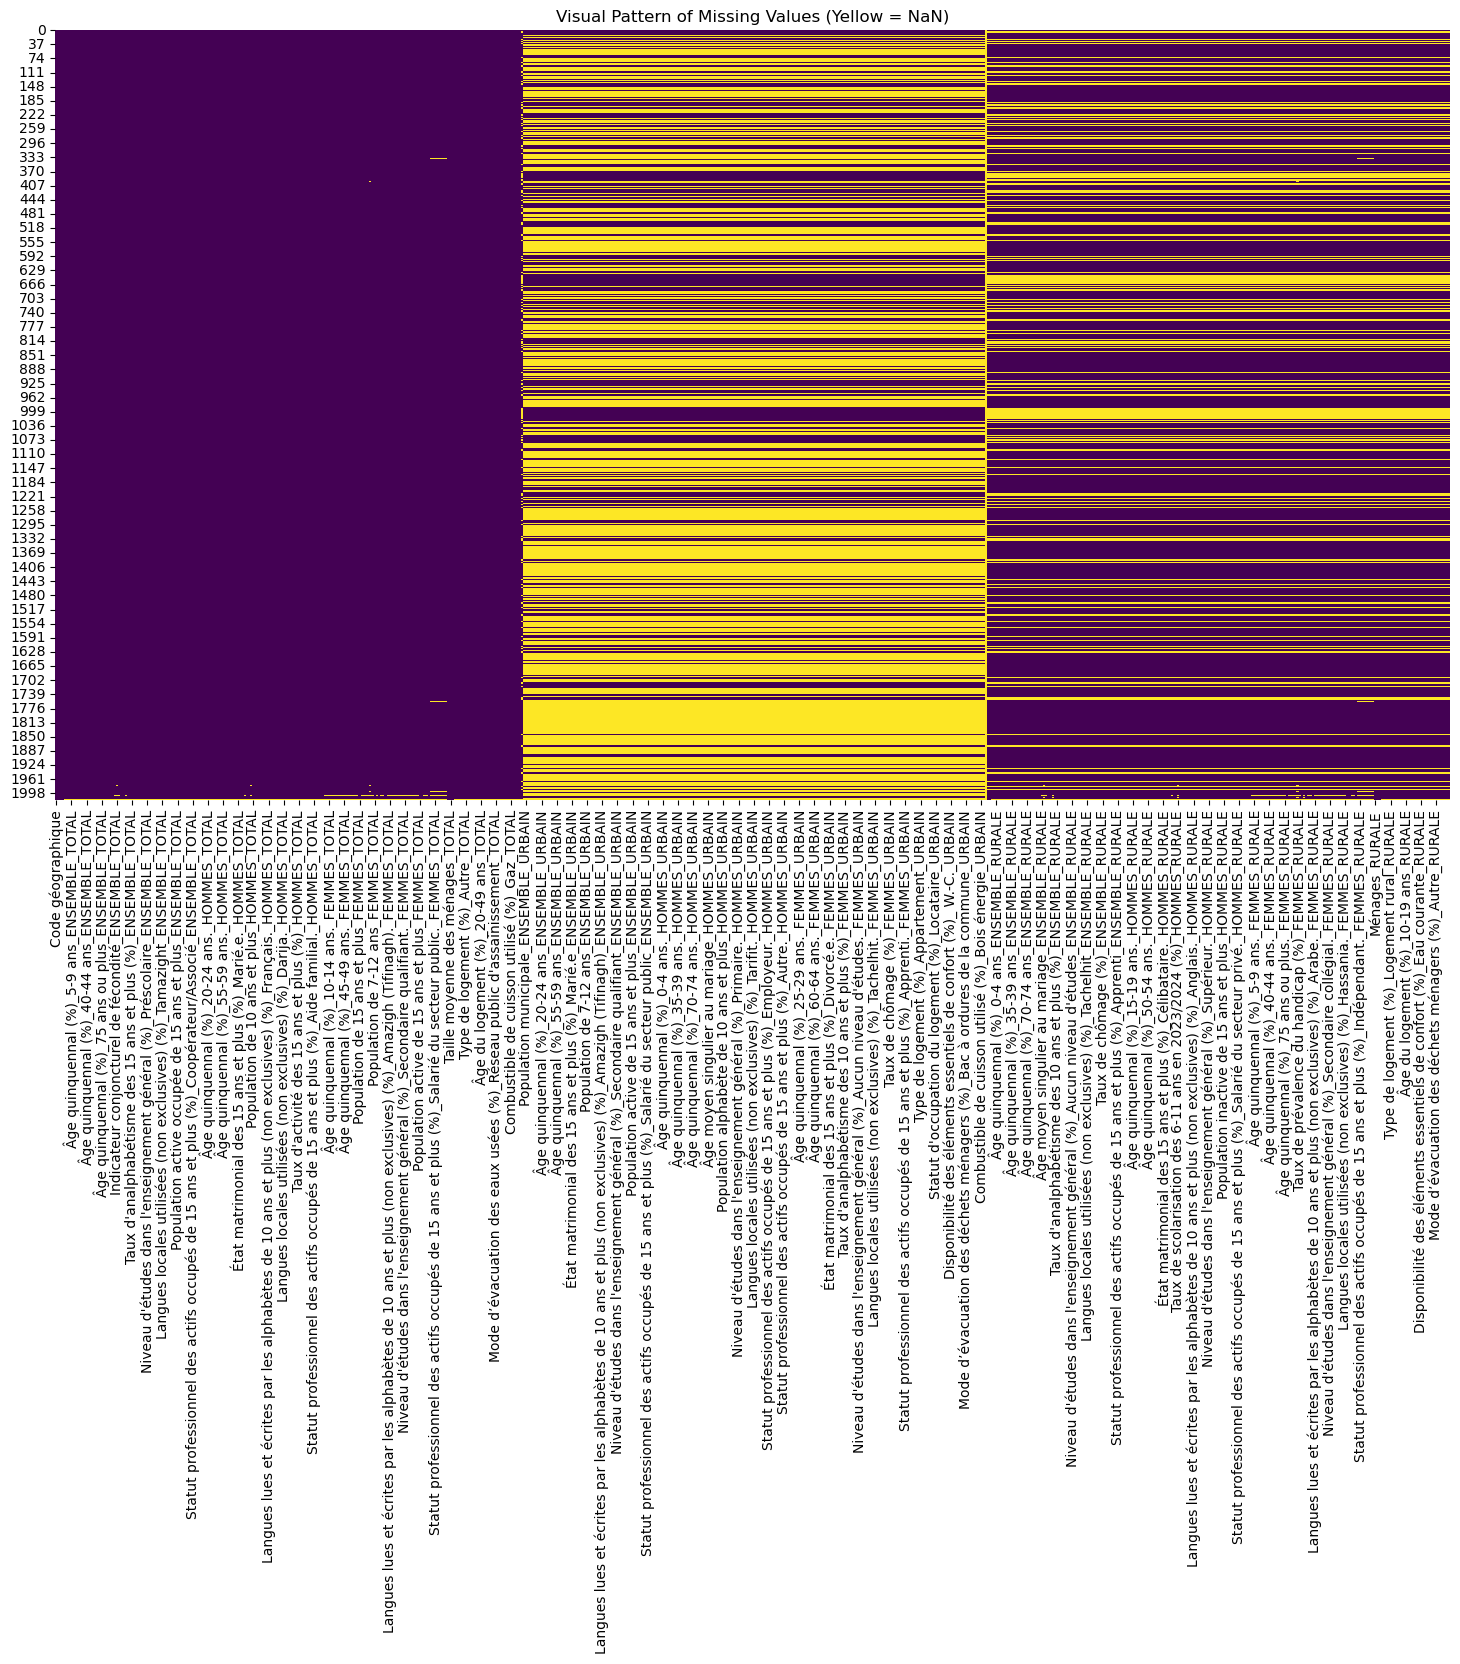

In [30]:

# Visualize Missing Values ---

plt.figure(figsize=(18, 10))
sns.heatmap(df_final_dataset.isnull(), cbar=False, cmap='viridis')
plt.title('Visual Pattern of Missing Values (Yellow = NaN)')
plt.show()


the first block (all over morocco), is almost entirely complete (dark purple ).there are only a few, sparse yellow dots, indicating random and idolated missing values.the middle block containing all the "URBAIN"COLUMNS" , shows a clear pattern, there are large horizontal bands of yellow, meaning that for certain territories (row), all the urban data is missing, which strogly suggest that these territories are 100% rural therefore have no urban data to report.same goes for 'RURALE' columns showing the inverse pattern suggesting simalarly that these terrirories are 100% urbain .'NaN's for both urbain and rural territories  likely mean "zero"s

### 3-2 Fixing missing data

#### 3-2-1 for the reverse pattern(urbain/rural)

- Hypothesis A: Rows with NaN in URBAIN columns are 100% rural territories.
- Hypothesis B: Rows with NaN in RURALE columns are 100% urban territories.

=> If the total population is equal to the rural population, the territory must be 100% rural. If the total population is equal to the urban population, it must be 100% urban.

- Verifying hypothesis A

In [34]:
total_pop_col = 'Population municipale_ENSEMBLE_TOTAL'
urban_pop_col = 'Population municipale_ENSEMBLE_URBAIN'
rural_pop_col = 'Population municipale_ENSEMBLE_RURALE'

# Find all rows where the URBAN population column is NaN
suspected_rural_territories = df_final_dataset[df_final_dataset[urban_pop_col].isnull()]
#verifying hypothesis A: are territories with NaN in URBAN COLUMNS 100% rural?
print(f"Found {len(suspected_rural_territories)} territories with NaN in the urban population column.")

if not suspected_rural_territories.empty:

    is_100_percent_rural = np.isclose(
        suspected_rural_territories[total_pop_col],
        suspected_rural_territories[rural_pop_col].fillna(0)
    )
    num_100_percent_rural = is_100_percent_rural.sum()
    print(f"verification result:{num_100_percent_rural} out of {len(suspected_rural_territories)} suspects are confirmed to be 100% rural")

    if num_100_percent_rural== len(suspected_rural_territories):
        print("Hypothesis A is confirmed with 100% accuracy.")
    else:
        print("Hypothesis A is not fully confirmed. Further investigation needed.")
        
        
        
        
    

Found 1232 territories with NaN in the urban population column.
verification result:1232 out of 1232 suspects are confirmed to be 100% rural
Hypothesis A is confirmed with 100% accuracy.


- Verifying hypothesis B

In [36]:
suspected_urban_territories =df_final_dataset[df_final_dataset[rural_pop_col].isnull()]
print(f"found {len(suspected_urban_territories)} territories with missing rural population data.")
if not suspected_urban_territories.empty:
    #checking if their TOTAL population is equal to their URBAIN population.
    is_100_percent_urbain= np.isclose(
        suspected_urban_territories[total_pop_col],
        suspected_urban_territories[urban_pop_col].fillna(0)
    )
    num_100_percent_urban = is_100_percent_urbain.sum()

    print(f"verification result: {num_100_percent_urban} out of {len(suspected_urban_territories)}suspects are confirmed to be 100% urban.")
    if num_100_percent_urban == len(suspected_urban_territories):
        print("hypothesis b is confirmed with 100% accuracy")
    else:
        print("hypothesis B is not fully confirmed. further investigation needed")

found 436 territories with missing rural population data.
verification result: 436 out of 436suspects are confirmed to be 100% urban.
hypothesis b is confirmed with 100% accuracy


- Treatment of the inverse pattern

In [38]:
print("\n--- Applying Data Treatment Based on Verified Hypothesis ---")
# Get a list of all columns that contain the word 'URBAIN' or 'RURALE'

urban_cols = [col for col in df_final_dataset.columns if 'URBAIN' in col]
rural_cols = [col for col in df_final_dataset.columns if 'RURALE' in col]
cols_to_fill_zero = urban_cols + rural_cols

for col in cols_to_fill_zero:
    df_final_dataset.loc[df_final_dataset[col].isnull(), col] = 0
print(f"successfully filled NaNs in {len(cols_to_fill_zero)} URBAN/RURAL columns with 0")



--- Applying Data Treatment Based on Verified Hypothesis ---
successfully filled NaNs in 428 URBAN/RURAL columns with 0


#### 3-2-2 for the sparse NaNs

In [44]:
numeric_cols_with_nan= df_final_dataset.select_dtypes(include=np.number).columns[
df_final_dataset.select_dtypes(include=np.number).isnull().any()].tolist()
if numeric_cols_with_nan:
    print(f"\nhandling {len(numeric_cols_with_nan)} columns with sparse,random NaNs...")
    for col in numeric_cols_with_nan:
        median_value = df_final_dataset[col].median()
        df_final_dataset.loc[df_final_dataset[col].isnull(), col]= median_value
        print(f"- Filled NaNs in '{col}' with its median ({median_value:.2f}).")
    print("successfully handled sparse NaNs.")
else:
    print("\nNo sparse NaNs found to impute with median.")




handling 209 columns with sparse,random NaNs...
- Filled NaNs in 'Sexe (%)_Masculin_ENSEMBLE_TOTAL' with its median (50.20).
- Filled NaNs in 'Sexe (%)_Féminin_ENSEMBLE_TOTAL' with its median (49.80).
- Filled NaNs in 'Âge quinquennal (%)_0-4 ans_ENSEMBLE_TOTAL' with its median (8.10).
- Filled NaNs in 'Âge quinquennal (%)_5-9 ans_ENSEMBLE_TOTAL' with its median (9.80).
- Filled NaNs in 'Âge quinquennal (%)_10-14 ans_ENSEMBLE_TOTAL' with its median (10.30).
- Filled NaNs in 'Âge quinquennal (%)_15-19 ans_ENSEMBLE_TOTAL' with its median (8.50).
- Filled NaNs in 'Âge quinquennal (%)_20-24 ans_ENSEMBLE_TOTAL' with its median (6.90).
- Filled NaNs in 'Âge quinquennal (%)_25-29 ans_ENSEMBLE_TOTAL' with its median (6.30).
- Filled NaNs in 'Âge quinquennal (%)_30-34 ans_ENSEMBLE_TOTAL' with its median (6.60).
- Filled NaNs in 'Âge quinquennal (%)_35-39 ans_ENSEMBLE_TOTAL' with its median (6.60).
- Filled NaNs in 'Âge quinquennal (%)_40-44 ans_ENSEMBLE_TOTAL' with its median (6.60).
- Filled 

#### 3-2-3 final verification 

In [46]:
remaining_nans = df_final_dataset.isnull().sum().sum()
if remaining_nans == 0:
    print("\n\n---STATUS: COMPLETE")
    print("dataset  is fully cleaned and has no missing values.")
else:
    print(f"there are still {remaining_nans} missing values to address.")
    print(df_final_dataset.isnull().sum()[df_final_dataset.isnull().sum() > 0])

    



---STATUS: COMPLETE
dataset  is fully cleaned and has no missing values.


In [47]:
df_final_dataset.to_csv("../data/df_final_dataset.csv",index=False)